# 5G O-RAN Intrusion Detection: Data Preprocessing and Baseline Model

This notebook implements the data engineering, preprocessing, and baseline machine learning modeling phase for the **5G O-RAN Security Exercise** using the `NetsLab-5GORAN-IDD` dataset.

### Objectives:
1. **Explore the Dataset:** Connect to `Network_Dataset.db` and analyze features and class distribution.
2. **Data Cleaning & Preprocessing:** Drop non-predictive identifier columns, replace Zeek's default string placeholders (`-`), handle any missing values, and verify numeric types.
3. **Categorical Encoding:** Encode categorical columns (`proto`, `service`, `conn_state`, `history`) and persist mappings for downstream enrichment.
4. **Class Balancing:** Balance heavily skewed classes using a hybrid downsampling and **SMOTE** (oversampling) strategy to achieve equal representation across classes.
5. **Baseline ML Model:** Train a multiclass `RandomForestClassifier` on the balanced dataset.
6. **Evaluation:** Evaluate the threat detector using per-class precision, recall, F1-scores, and a Confusion Matrix.
7. **CTI Alert Prep:** Save predicted test events with confidence scores for downstream LLM-based Threat Intelligence.

## 1. Import Libraries

In [1]:
import os
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 8)
print("All libraries successfully imported.")

All libraries successfully imported.


## 2. Load Data from SQLite

We connect to `../data/Network_Dataset.db` and query the schema and raw class counts. Because the full dataset contains 1.7 million rows, loading the entire dataset into memory for SMOTE and model training can lead to significant resource consumption. To optimize memory and training speed while keeping the dataset representative, we load a balanced subset containing up to 50,000 records per class.

In [2]:
DB_PATH = "../data/Network_Dataset.db"
conn = sqlite3.connect(DB_PATH)

# Check all unique attack categories and counts
print("Raw class counts in database:")
counts_df = pd.read_sql_query(
    "SELECT attack_category, COUNT(*) as count FROM Network_Data GROUP BY attack_category", 
    conn
)
print(counts_df)

# Load a balanced sample from the database
classes = ['benign', 'dos', 'ddos', 'probe', 'bruteforce', 'web']
dfs = []
max_samples_per_class = 50000

print("\nLoading class subsets...")
for c in classes:
    query = f"SELECT * FROM Network_Data WHERE attack_category = '{c}'"
    df_class = pd.read_sql_query(query, conn)
    print(f"  Class '{c}': {len(df_class)} rows found")
    if len(df_class) > max_samples_per_class:
        df_class = df_class.sample(n=max_samples_per_class, random_state=42)
    dfs.append(df_class)

conn.close()
df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined raw sample dataset size: {len(df_raw)} rows.")

Raw class counts in database:


  attack_category   count
0          benign  170865
1      bruteforce   28566
2            ddos  420282
3             dos  632507
4           probe  183293
5             web  288304

Loading class subsets...


  Class 'benign': 170865 rows found


  Class 'dos': 632507 rows found


  Class 'ddos': 420282 rows found


  Class 'probe': 183293 rows found


  Class 'bruteforce': 28566 rows found


  Class 'web': 288304 rows found

Combined raw sample dataset size: 278566 rows.


## 3. Data Cleaning

We drop identifiers and non-predictive columns (`uid`, `src_ip`, `dst_ip`, `src_port`, `dst_port`, `traffic_type`, `attack_type`). Keeping host-specific IP addresses would cause the model to overfit to the testbed environment instead of learning generalizable protocol signatures. We also replace Zeek's default string hyphen (`-`) placeholder with `'none'` and ensure all numeric columns are correctly typed and free of missing values.

In [3]:
print("Performing data cleaning...")

# Drop non-predictive fields
cols_to_drop = ['uid', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'traffic_type', 'attack_type']
df_clean = df_raw.drop(columns=cols_to_drop)

# Handle hyphens in categorical features
df_clean['service'] = df_clean['service'].replace('-', 'none')
df_clean['history'] = df_clean['history'].replace('-', 'none')

# Ensure all numeric columns are floats/ints and fill nulls with 0
numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
    'ip_proto', 'http_trans_depth', 'files_total_bytes',
    'is_GET_mthd', 'http_status_error', 'is_file_transfered'
]
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

print(f"Cleaned dataset columns: {list(df_clean.columns)}")
print("Missing value count:")
print(df_clean.isnull().sum())

Performing data cleaning...


Cleaned dataset columns: ['proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'history', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'attack_category', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered']
Missing value count:


proto                 0
service               0
duration              0
src_bytes             0
dst_bytes             0
conn_state            0
missed_bytes          0
history               0
src_pkts              0
src_ip_bytes          0
dst_pkts              0
dst_ip_bytes          0
ip_proto              0
http_trans_depth      0
attack_category       0
files_total_bytes     0
is_GET_mthd           0
http_status_error     0
is_file_transfered    0
dtype: int64


## 4. Categorical Feature Encoding

We map the categorical columns (`proto`, `service`, `conn_state`, `history`) to numeric indices. Crucially, we persist the encoding dictionaries to joblib files, enabling consistent mappings when generating or enriching CTI alerts downstream.

In [4]:
print("Encoding categorical variables...")
categorical_cols = ['proto', 'service', 'conn_state', 'history']
encoding_mappings = {}

for col in categorical_cols:
    # Extract unique categories and build mapping dictionary
    unique_vals = sorted(df_clean[col].astype(str).unique())
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    encoding_mappings[col] = mapping
    
    # Apply mapping
    df_clean[col] = df_clean[col].astype(str).map(mapping)

# Ensure target directory exists and save mappings
os.makedirs("../models", exist_ok=True)
joblib.dump(encoding_mappings, "../models/encoding_mappings.joblib")
print("Saved categorical encoding mappings to '../models/encoding_mappings.joblib'")

Encoding categorical variables...


Saved categorical encoding mappings to '../models/encoding_mappings.joblib'


## 5. Handle Target Labels

We encode the multiclass target `attack_category` and save the target mappings.

In [5]:
target_col = 'attack_category'
target_labels = sorted(df_clean[target_col].unique())
target_mapping = {val: idx for idx, val in enumerate(target_labels)}
reverse_target_mapping = {idx: val for val, idx in target_mapping.items()}

joblib.dump({'mapping': target_mapping, 'reverse': reverse_target_mapping}, "../models/target_mapping.joblib")
df_clean[target_col] = df_clean[target_col].map(target_mapping)

print(f"Target class mapping: {target_mapping}")

Target class mapping: {'benign': 0, 'bruteforce': 1, 'ddos': 2, 'dos': 3, 'probe': 4, 'web': 5}


## 6. Class Balancing via SMOTE

Since our classes are highly unbalanced (e.g. `dos` has 632k records, while `bruteforce` has only 28.5k), we use a hybrid balancing strategy. We downsampled majority classes to 50,000 records in Section 2. Now we apply SMOTE (Synthetic Minority Over-sampling Technique) to upsample minority classes (like `bruteforce`) to 50,000 records, creating a perfectly balanced dataset.

In [6]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Original target counts per class:")
print(y.value_counts().rename(reverse_target_mapping))

print("\nApplying SMOTE...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nBalanced target counts per class:")
print(pd.Series(y_resampled).value_counts().rename(reverse_target_mapping))

Original target counts per class:
attack_category
benign        50000
dos           50000
ddos          50000
probe         50000
web           50000
bruteforce    28566
Name: count, dtype: int64

Applying SMOTE...



Balanced target counts per class:
attack_category
benign        50000
dos           50000
ddos          50000
probe         50000
bruteforce    50000
web           50000
Name: count, dtype: int64


## 7. Train-Test Split & Feature Scaling

We split the balanced dataset into an 80% training set and 20% test set (maintaining stratified class ratios) and apply feature scaling.

In [7]:
print("Splitting dataset...")
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_resampled
)

print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "../models/scaler.joblib")
print("Scaler saved to '../models/scaler.joblib'")

Splitting dataset...
Scaling features...


Scaler saved to '../models/scaler.joblib'


## 8. Train Baseline Machine Learning Model

We train a multiclass `RandomForestClassifier` with 100 decision trees to serve as our baseline threat detector.

In [8]:
print("Training Random Forest classifier (this may take a moment)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

joblib.dump(rf_model, "../models/random_forest_model.joblib")
print("Model saved to '../models/random_forest_model.joblib'")

Training Random Forest classifier (this may take a moment)...


Model saved to '../models/random_forest_model.joblib'


## 9. Model Evaluation

We evaluate the threat detection accuracy using per-class precision, recall, F1-scores, and display a visual confusion matrix.

Overall Classification Accuracy: 0.9166

Classification Report:
              precision    recall  f1-score   support

      benign       0.94      0.87      0.90     10000
  bruteforce       0.83      0.96      0.89     10000
        ddos       0.93      0.87      0.90     10000
         dos       0.84      0.91      0.88     10000
       probe       0.99      0.90      0.94     10000
         web       1.00      0.99      0.99     10000

    accuracy                           0.92     60000
   macro avg       0.92      0.92      0.92     60000
weighted avg       0.92      0.92      0.92     60000



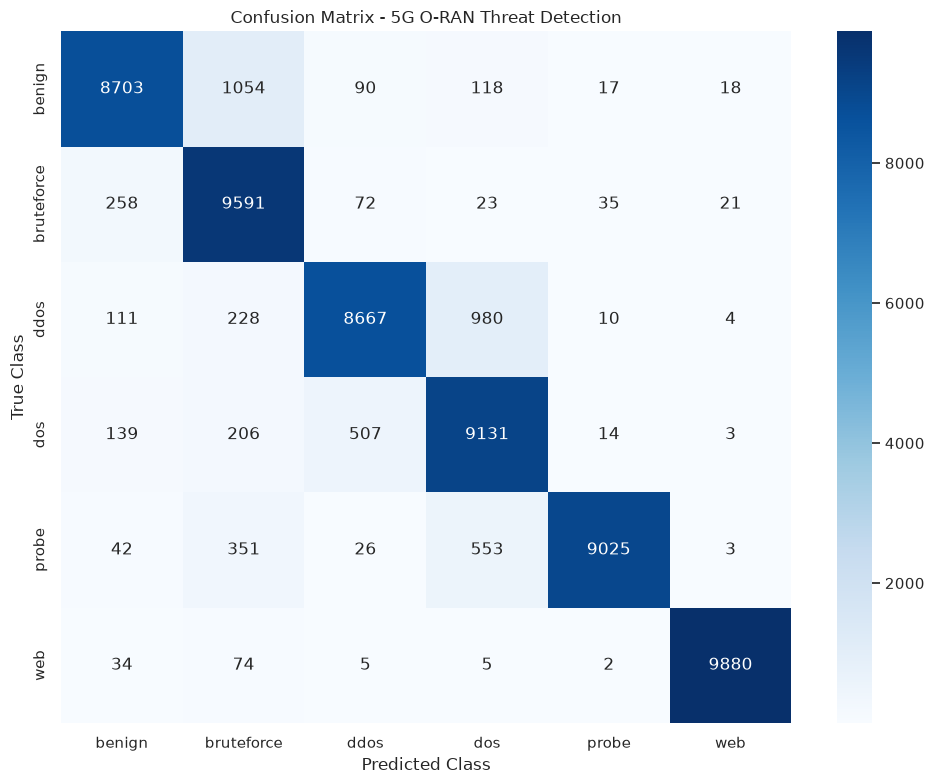

Analyzing commonly confused attacks:
  True Class 'benign' commonly misclassified as 'bruteforce' (1054 times)
  True Class 'benign' commonly misclassified as 'dos' (118 times)
  True Class 'bruteforce' commonly misclassified as 'benign' (258 times)
  True Class 'ddos' commonly misclassified as 'benign' (111 times)
  True Class 'ddos' commonly misclassified as 'bruteforce' (228 times)
  True Class 'ddos' commonly misclassified as 'dos' (980 times)
  True Class 'dos' commonly misclassified as 'benign' (139 times)
  True Class 'dos' commonly misclassified as 'bruteforce' (206 times)
  True Class 'dos' commonly misclassified as 'ddos' (507 times)
  True Class 'probe' commonly misclassified as 'bruteforce' (351 times)
  True Class 'probe' commonly misclassified as 'dos' (553 times)


In [9]:
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)

# Display overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Classification Accuracy: {accuracy:.4f}\n")

# Classification report
target_names = [reverse_target_mapping[i] for i in range(len(target_labels))]
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=target_names, 
    yticklabels=target_names
)
plt.title("Confusion Matrix - 5G O-RAN Threat Detection")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=300)
plt.show()

# Analyze commonly confused attacks
print("Analyzing commonly confused attacks:")
for i in range(len(target_names)):
    for j in range(len(target_names)):
        if i != j and conf_matrix[i, j] > 100:
            print(f"  True Class '{target_names[i]}' commonly misclassified as '{target_names[j]}' ({conf_matrix[i, j]} times)")

## 10. Record Predictions for CTI Enrichment

To support downstream LLM enrichment, we map the scaled/encoded test data back to their original human-readable strings, append predictions and confidence scores, and save them to a structured test event file (`../data/cti_test_events.csv`).

In [10]:
print("Constructing CTI test event database...")
df_test_events = pd.DataFrame(X_test.copy())

# Map numeric category codes back to strings for clarity
for col in categorical_cols:
    rev_map = {idx: val for val, idx in encoding_mappings[col].items()}
    df_test_events[col] = df_test_events[col].map(rev_map)

# Add label outcomes
df_test_events['true_label'] = pd.Series(y_test).map(reverse_target_mapping).values
df_test_events['predicted_label'] = pd.Series(y_pred).map(reverse_target_mapping).values
df_test_events['confidence'] = np.max(y_pred_proba, axis=1)

# Append prediction probabilities to provide alternative predictions for the LLM
for idx, label in reverse_target_mapping.items():
    df_test_events[f'prob_{label}'] = y_pred_proba[:, idx]

# Save data
os.makedirs("../data", exist_ok=True)
df_test_events.to_csv("../data/cti_test_events.csv", index=False)
print(f"Saved {len(df_test_events)} test events to '../data/cti_test_events.csv'")

Constructing CTI test event database...


Saved 60000 test events to '../data/cti_test_events.csv'
